# Marketing Campaigns

IITK AIML / Applied Data Science with Python

Looking at what drives customer acquisition in this marketing mix data. People stuff (age, education, income), product spend, place (web / catalog / store), and the campaign flags.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

spend_cols = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
]
channel_cols = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]

# Basic -> PhD
edu_order = {"Basic": 0, "Graduation": 1, "2n Cycle": 2, "Master": 3, "PhD": 4}


## Import check

First thing I noticed: `Income` has a space in the header and values like `$84,835.00`. `Dt_Customer` is written as `6/16/14`. Had to fix both before anything else.


In [2]:
df = pd.read_csv("marketing_data.csv")
df.columns = df.columns.str.strip()
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [3]:
def parse_income(val):
    if pd.isna(val):
        return np.nan
    text = str(val).replace("$", "").replace(",", "").strip()
    if text == "" or text.lower() == "nan":
        return np.nan
    try:
        return float(text)
    except ValueError:
        return np.nan

df["Income"] = df["Income"].apply(parse_income)
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%m/%d/%y", errors="coerce")

print("shape:", df.shape)
print(df[["Dt_Customer", "Income"]].dtypes)
print("missing Income:", int(df["Income"].isna().sum()))
df[["ID", "Education", "Marital_Status", "Income", "Dt_Customer"]].head()


shape: (2240, 28)
Dt_Customer    datetime64[ns]
Income                float64
dtype: object
missing Income: 24


,ID,Education,Marital_Status,Income,Dt_Customer
0,1826,Graduation,Divorced,84835.0,2014-06-16
1,1,Graduation,Single,57091.0,2014-06-15
2,10476,Graduation,Married,67267.0,2014-05-13
3,1386,Graduation,Together,32474.0,2014-05-11
4,5371,Graduation,Single,21474.0,2014-04-08


## Category cleanup + missing income

Brief said fill blank incomes using similar education and marital status. So first check what those categories even look like.


In [4]:
print("Education:", df["Education"].unique().tolist())
print("Marital:", df["Marital_Status"].unique().tolist())
print(df["Education"].value_counts())
print()
print(df["Marital_Status"].value_counts())


Education: ['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic']
Marital: ['Divorced', 'Single', 'Married', 'Together', 'Widow', 'YOLO', 'Alone', 'Absurd']
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
YOLO          2
Absurd        2
Name: count, dtype: int64


Education looks fine. Marital has Alone / YOLO / Absurd mixed in. Putting those under Single.


In [5]:
df["Marital_Status"] = df["Marital_Status"].replace(
    {"Alone": "Single", "YOLO": "Single", "Absurd": "Single"}
)
print(df["Marital_Status"].value_counts())


Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64


In [6]:
# fill with education + marital median, overall median as backup
df["Income"] = df.groupby(["Education", "Marital_Status"])["Income"].transform(
    lambda s: s.fillna(s.median())
)
df["Income"] = df["Income"].fillna(df["Income"].median())
print("missing Income after fill:", int(df["Income"].isna().sum()))


missing Income after fill: 0


## Extra columns

Need Children, Age, TotalSpend, and TotalPurchases (web + catalog + store).

Age as `2014 - Year_Birth` since most join dates in this file are 2014.


In [7]:
df["Age"] = 2014 - df["Year_Birth"]
df["Children"] = df["Kidhome"] + df["Teenhome"]
df["TotalSpend"] = df[spend_cols].sum(axis=1)
df["TotalPurchases"] = df[channel_cols].sum(axis=1)

df[["Year_Birth", "Age", "Kidhome", "Teenhome", "Children",
    "TotalSpend", "TotalPurchases"]].head()


,Year_Birth,Age,Kidhome,Teenhome,Children,TotalSpend,TotalPurchases
0,1970,44,0,0,0,1190,14
1,1961,53,0,0,0,577,17
2,1958,56,0,1,1,251,10
3,1967,47,1,1,2,11,3
4,1989,25,1,0,1,91,6


## Distributions / outliers

Quick look at boxplots first.


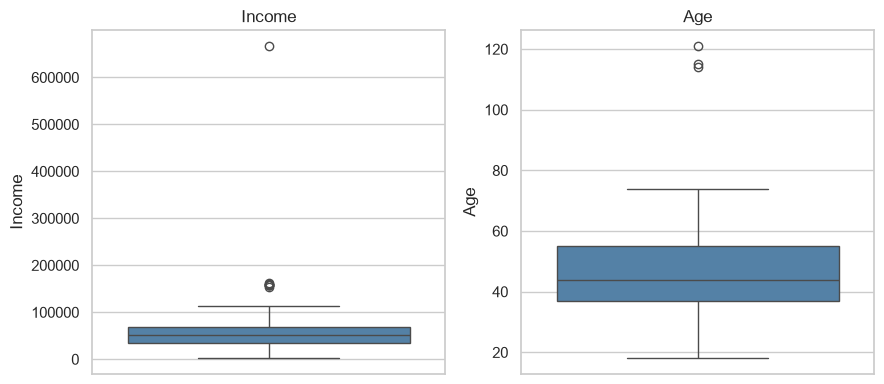

In [8]:
fig, ax = plt.subplots(1, 2)
sns.boxplot(y=df["Income"], ax=ax[0], color="steelblue")
ax[0].set_title("Income")
sns.boxplot(y=df["Age"], ax=ax[1], color="steelblue")
ax[1].set_title("Age")
plt.tight_layout()
plt.show()


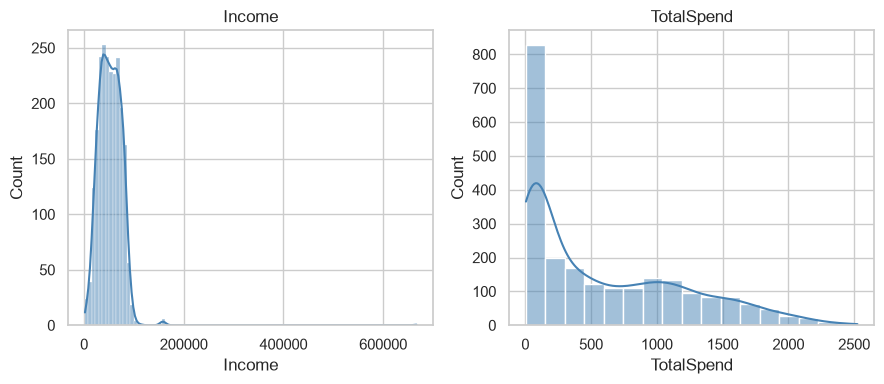

In [9]:
fig, ax = plt.subplots(1, 2)
sns.histplot(df["Income"], kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Income")
sns.histplot(df["TotalSpend"], kde=True, ax=ax[1], color="steelblue")
ax[1].set_title("TotalSpend")
plt.tight_layout()
plt.show()


One income is 666666 which is nonsense, and a couple Year_Birth values are way too old. Cutting those.


In [10]:
print("rows before:", len(df))
df = df[df["Income"] < 200000]
df = df[df["Year_Birth"] >= 1940].reset_index(drop=True)
print("rows after:", len(df))


rows before: 2240
rows after: 2236


## Encoding

Education has order so ordinal. Marital and Country get one-hot.


In [11]:
df["Education_ord"] = df["Education"].map(edu_order)
df[["Education", "Education_ord"]].drop_duplicates().sort_values("Education_ord")


,Education,Education_ord
54,Basic,0
0,Graduation,1
6,2n Cycle,2
11,Master,3
5,PhD,4


In [12]:
marital_dummies = pd.get_dummies(df["Marital_Status"], prefix="Marital")
country_dummies = pd.get_dummies(df["Country"], prefix="Country")
df = pd.concat([df, marital_dummies, country_dummies], axis=1)

print("dummy cols:", list(marital_dummies.columns) + list(country_dummies.columns))
df.shape


dummy cols: ['Marital_Divorced', 'Marital_Married', 'Marital_Single', 'Marital_Together', 'Marital_Widow', 'Country_AUS', 'Country_CA', 'Country_GER', 'Country_IND', 'Country_ME', 'Country_SA', 'Country_SP', 'Country_US']


(2236, 46)

## Correlation heatmap


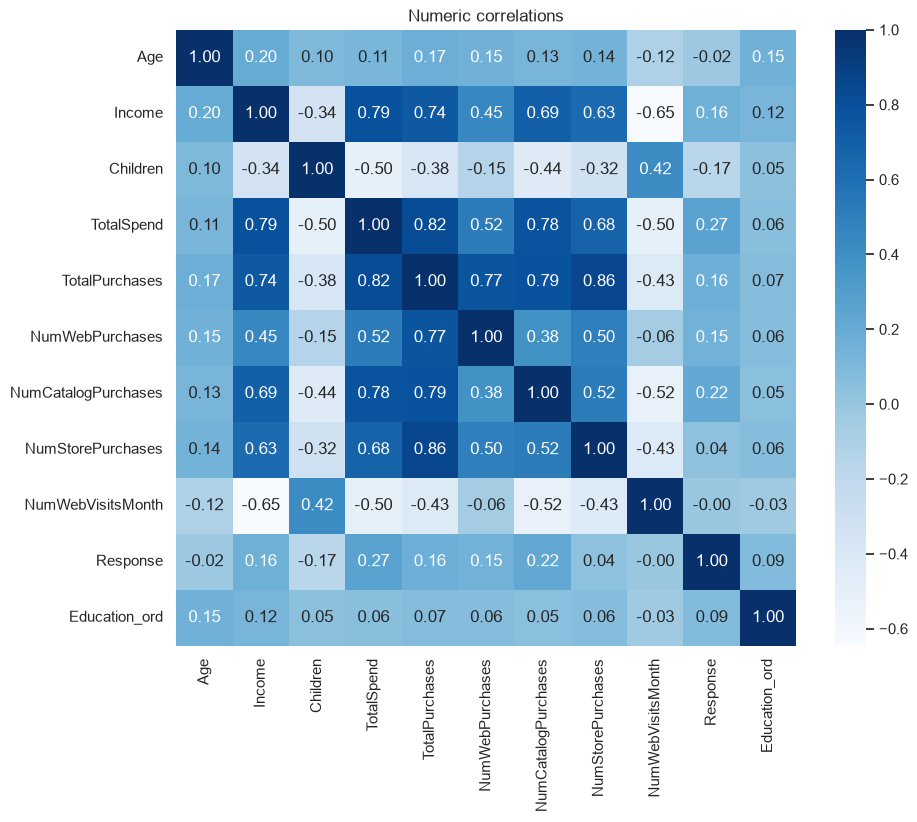

In [13]:
corr_cols = [
    "Age", "Income", "Children", "TotalSpend", "TotalPurchases",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
    "NumWebVisitsMonth", "Response", "Education_ord",
]
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Numeric correlations")
plt.show()


Income and TotalSpend are clearly linked. More kids generally means less spend. Education_ord doesn't do much here.


## Hypothesis tests

Using alpha = 0.05.


### H1 - older people lean toward in-store?

Split at median age, compare `NumStorePurchases`.


In [14]:
age_mid = df["Age"].median()
old_store = df.loc[df["Age"] >= age_mid, "NumStorePurchases"]
young_store = df.loc[df["Age"] < age_mid, "NumStorePurchases"]

t1, p1 = stats.ttest_ind(old_store, young_store, equal_var=False)
print("median age:", age_mid)
print("old mean:", round(old_store.mean(), 3), "n =", len(old_store))
print("young mean:", round(young_store.mean(), 3), "n =", len(young_store))
print("t =", round(t1, 3), "p =", round(p1, 4))


median age: 44.0
old mean: 6.233 n = 1150
young mean: 5.332 n = 1086
t = 6.61 p = 0.0


Older group buys more in store (about 6.2 vs 5.3) and p is basically 0. Holds at alpha = 0.05.


### H2 - customers with kids shop more online?

Compare `NumWebPurchases` for Children > 0 vs 0.


In [15]:
web_kids = df.loc[df["Children"] > 0, "NumWebPurchases"]
web_none = df.loc[df["Children"] == 0, "NumWebPurchases"]

t2, p2 = stats.ttest_ind(web_kids, web_none, equal_var=False)
print("kids mean:", round(web_kids.mean(), 3), "n =", len(web_kids))
print("no kids mean:", round(web_none.mean(), 3), "n =", len(web_none))
print("t =", round(t2, 3), "p =", round(p2, 4))


kids mean: 3.966 n = 1599
no kids mean: 4.394 n = 637
t = -3.512 p = 0.0005


Went the other way. Web mean is lower with kids (3.97 vs 4.39), p = 0.0005. So not supporting "parents shop online because they're busy".


### H3 - do other channels cannibalize store sales?

If web + catalog were eating store sales, corr with store should be negative.


In [16]:
other_channels = df["NumWebPurchases"] + df["NumCatalogPurchases"]
store_corr = df["NumStorePurchases"].corr(other_channels)
print("store vs web+catalog corr:", round(store_corr, 3))


store vs web+catalog corr: 0.615


Corr is about +0.62. Heavy buyers seem to use all channels. No clear cannibalization signal here.


### H4 - does US beat the rest of the world on total purchases?


In [17]:
us_buys = df.loc[df["Country"] == "US", "TotalPurchases"]
rest_buys = df.loc[df["Country"] != "US", "TotalPurchases"]

t4, p4 = stats.ttest_ind(us_buys, rest_buys, equal_var=False)
print("US mean:", round(us_buys.mean(), 3), "n =", len(us_buys))
print("rest mean:", round(rest_buys.mean(), 3), "n =", len(rest_buys))
print("t =", round(t4, 3), "p =", round(p4, 4))


US mean: 13.514 n = 109
rest mean: 12.497 n = 2127
t = 1.454 p = 0.1486


US mean is a bit higher (13.5 vs 12.5) but p = 0.15 and n_US is only 109. Not significant at alpha = 0.05.


## Product revenue


In [18]:
product_totals = df[spend_cols].sum().sort_values(ascending=False)
print(product_totals)


MntWines            680029
MntMeatProducts     373375
MntGoldProds         98346
MntFishProducts      83931
MntSweetProducts     60552
MntFruits            58753
dtype: int64


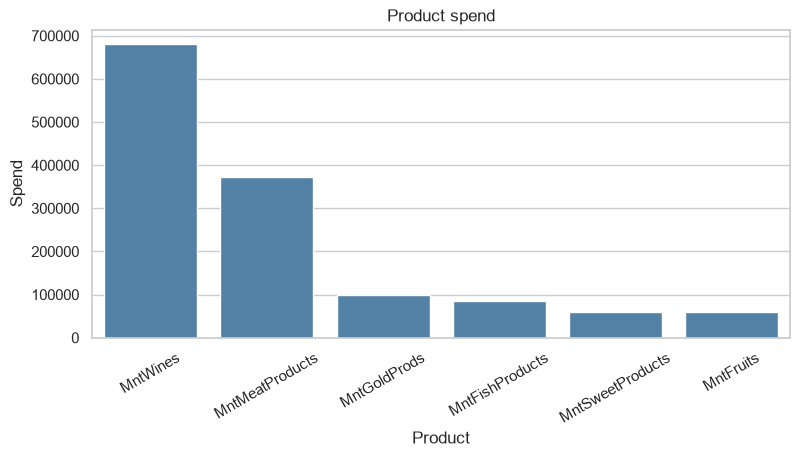

In [19]:
prod = product_totals.reset_index()
prod.columns = ["Product", "Spend"]

plt.figure()
sns.barplot(data=prod, x="Product", y="Spend", color="steelblue")
plt.xticks(rotation=30)
plt.title("Product spend")
plt.show()


Wine is way ahead. Fruit and sweets are the low ones.


## Age vs last campaign (Response)


Age vs Response corr: -0.019


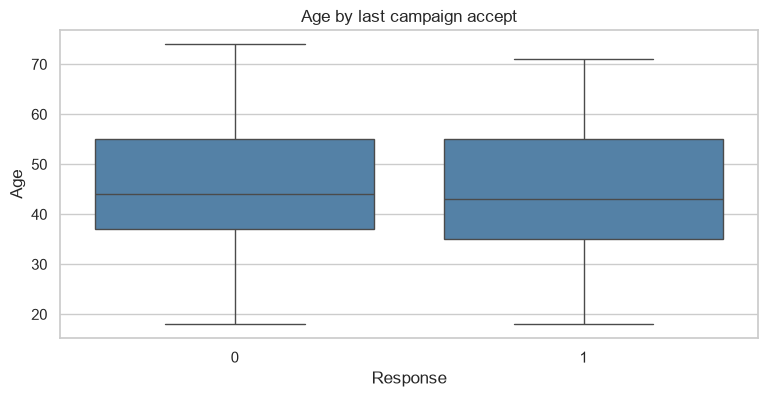

In [20]:
print("Age vs Response corr:", round(df["Age"].corr(df["Response"]), 3))

plt.figure()
sns.boxplot(data=df, x="Response", y="Age", color="steelblue")
plt.title("Age by last campaign accept")
plt.show()


Corr is basically zero (-0.02). Age doesn't really move with accepting the last campaign.


## Country with most last-campaign accepts


Country
SP     176
SA      52
CA      38
AUS     23
GER     17
IND     13
US      13
ME       2
Name: Response, dtype: int64


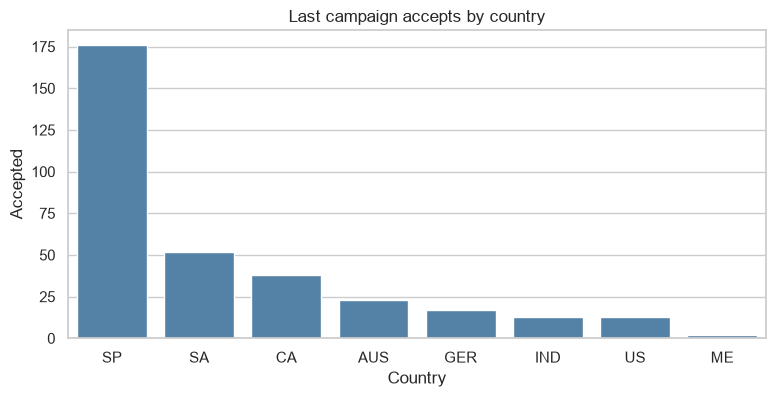

In [21]:
accepts_by_country = df.groupby("Country")["Response"].sum().sort_values(ascending=False)
print(accepts_by_country)

camp = accepts_by_country.reset_index()
camp.columns = ["Country", "Accepted"]

plt.figure()
sns.barplot(data=camp, x="Country", y="Accepted", color="steelblue")
plt.title("Last campaign accepts by country")
plt.show()


Spain is on top. Spain also has the most customers in this file though, so part of that is just sample size.


## Children at home vs total spend


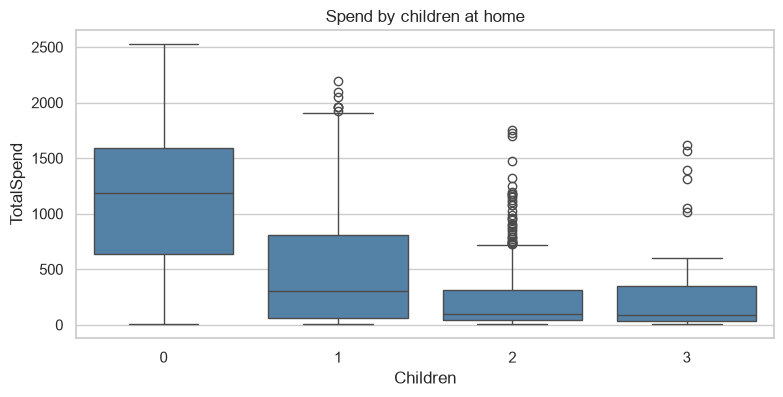

In [22]:
plt.figure()
sns.boxplot(data=df, x="Children", y="TotalSpend", color="steelblue")
plt.title("Spend by children at home")
plt.show()


Spend falls once Children > 0. Matches what the heatmap showed.


## Complaints in last 2 years by education


Education
Graduation    14
2n Cycle       3
Master         2
PhD            1
Name: count, dtype: int64


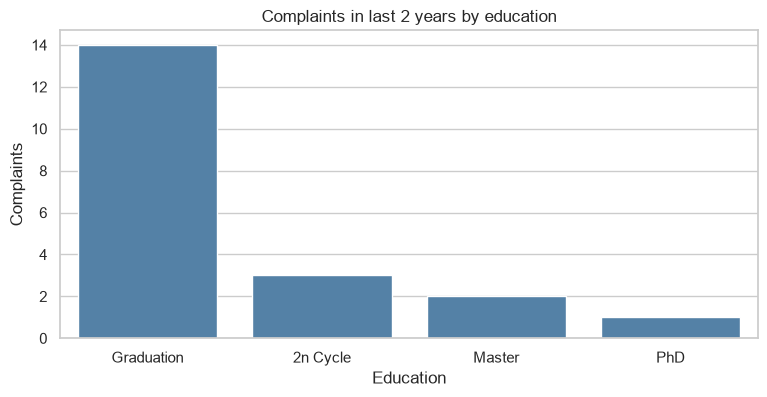

In [23]:
print(df.loc[df["Complain"] == 1, "Education"].value_counts())

complain_edu = df.loc[df["Complain"] == 1, "Education"].value_counts().reset_index()
complain_edu.columns = ["Education", "Complaints"]

plt.figure()
sns.barplot(data=complain_edu, x="Education", y="Complaints", color="steelblue")
plt.title("Complaints in last 2 years by education")
plt.show()


Only about 20 complaints total. Graduation shows up most, and that's also the biggest education group, so I'm not reading too much into it.

One limit: cannibalization was only checked with correlation, not a full model. Also Age is anchored to 2014 because that's when people joined in this file.
